In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

# Parte 1 - Leitura + EDA

In [2]:
# Leitura correta do CSV (separador, decimal, encoding)
df = pd.read_csv(r'C:\Users\gabri\OneDrive\Documentos\MBA\Trabalhos\Applied Statistics\Base_ScoreCredito_QuantumFinance(8).csv', sep = ";")
# Identificar o target e documentar todas as variáveis (o que cada uma significa)
# Tratamento de nulos e outliers
# EDA: descritiva de cada variável, histogramas, boxplots
# Entrega interna: um dataframe limpo + a lista de variáveis, que os outros dois vão usar

In [3]:
# Identificar o target e documentar todas as variáveis (o que cada uma significa)
df

,id,idade,sexo,estado_civil,escola,Qte_dependentes,tempo_ultimoservico,trabalha,vl_salario_mil,reg_moradia,casa_propria,vl_imovel_em_mil,Qte_cartoes,Qte_carros,SCORE_CREDITO
0,708082083,45,F,casado,graduacao,3,40,1,"40,089665024322",3,0,0,1,1,778
1,708083283,58,M,solteiro,ensino fundam,0,44,1,"66,557645274838",3,0,0,1,0,"276,3"
2,708084558,46,M,divorciado,doutorado,3,35,1,"123,68182089138",6,0,0,1,1,401
3,708085458,34,F,solteiro,mestrado,0,22,1,"19,7159343168329",6,0,0,1,0,"347,4"
4,708086958,49,F,casado,mestrado,2,36,0,0,3,1,437,1,2,476
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10122,828288333,50,M,casado,mestrado,0,45,1,"100,128970755",4,0,0,1,0,470
10123,828291858,38,M,solteiro,ensino fundam,0,31,1,"89,80599574656",6,0,0,1,1,432
10124,828294933,49,F,casado,graduacao,3,43,1,"19,7993057098452",3,1,252,1,1,406
10125,828298908,54,M,casado,ensino medio,4,48,1,"194,78317642784",4,0,0,1,1,387


In [4]:
y = df["SCORE_CREDITO"]
X = df.drop(columns = "SCORE_CREDITO")

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   id                   10127 non-null  int64
 1   idade                10127 non-null  int64
 2   sexo                 10127 non-null  str  
 3   estado_civil         10127 non-null  str  
 4   escola               10127 non-null  str  
 5   Qte_dependentes      10127 non-null  int64
 6   tempo_ultimoservico  10127 non-null  int64
 7   trabalha             10127 non-null  int64
 8   vl_salario_mil       10127 non-null  str  
 9   reg_moradia          10127 non-null  int64
 10  casa_propria         10127 non-null  int64
 11  vl_imovel_em_mil     10127 non-null  int64
 12  Qte_cartoes          10127 non-null  int64
 13  Qte_carros           10127 non-null  int64
 14  SCORE_CREDITO        10127 non-null  str  
dtypes: int64(10), str(5)
memory usage: 1.2 MB


In [6]:
df.describe()

,id,idade,Qte_dependentes,tempo_ultimoservico,trabalha,reg_moradia,casa_propria,vl_imovel_em_mil,Qte_cartoes,Qte_carros
count,1.012700e+04,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000
mean,7.391776e+08,46.325960,1.547447,34.133208,0.911919,3.783450,0.352424,208.999111,1.083638,0.623383
std,3.690378e+07,8.016814,1.489079,8.221428,0.283427,1.580486,0.477749,378.495229,0.333784,0.569796
min,7.080821e+08,26.000000,0.000000,7.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000
25%,7.130368e+08,41.000000,0.000000,30.000000,1.000000,3.000000,0.000000,0.000000,1.000000,0.000000
50%,7.179264e+08,46.000000,1.000000,34.000000,1.000000,4.000000,0.000000,0.000000,1.000000,1.000000
75%,7.731435e+08,52.000000,3.000000,39.000000,1.000000,5.000000,1.000000,289.000000,1.000000,1.000000
max,8.283431e+08,73.000000,5.000000,57.000000,1.000000,6.000000,1.000000,1800.000000,4.000000,2.000000


In [7]:
# Tratamento de nulos
df.isna().sum().sort_values(ascending=False)

id                     0
idade                  0
sexo                   0
estado_civil           0
escola                 0
Qte_dependentes        0
tempo_ultimoservico    0
trabalha               0
vl_salario_mil         0
reg_moradia            0
casa_propria           0
vl_imovel_em_mil       0
Qte_cartoes            0
Qte_carros             0
SCORE_CREDITO          0
dtype: int64

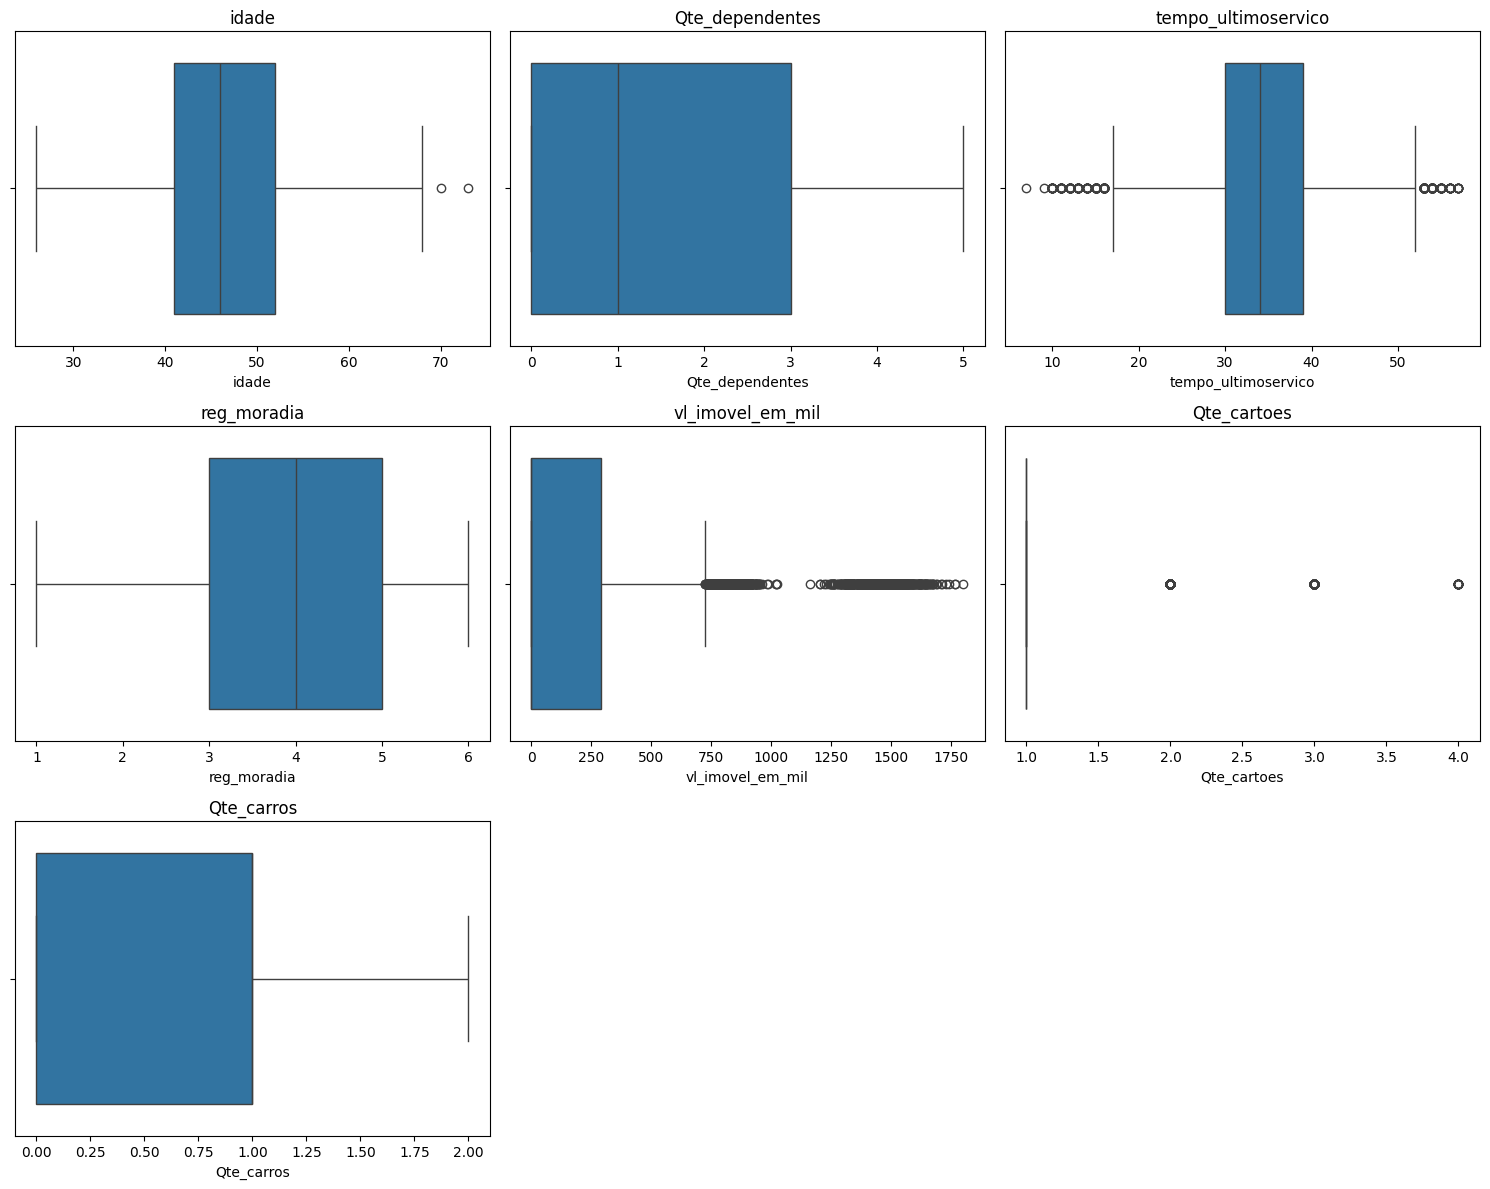

In [8]:
# Tratamento de outliers
colunas_numericas = df.select_dtypes(include = "number").drop(columns = ["id", "trabalha", "casa_propria"]).columns
n = len(colunas_numericas)
n_cols = 3
n_linhas = (n + n_cols - 1) // n_cols   # arredonda pra cima

fig, axes = plt.subplots(n_linhas, n_cols, figsize=(15, 4 * n_linhas))
axes = axes.flatten()   # transforma a grade num vetor pra iterar fácil

for i, coluna in enumerate(colunas_numericas):
    sns.boxplot(x=df[coluna], ax=axes[i])
    axes[i].set_title(coluna)

# remove os quadros vazios que sobram na grade
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [ ]:
# Quantidade de outliers por coluna (Valor imovel e Tempo serviço)
valor_imovel = df["vl_imovel_em_mil"]



In [10]:

# id = código de identificação do usuário, representado por números inteiros
## Tipo: Qualitativa Nominal 
# idade = idade do cliente, representado por números inteiros
## Tipo: Quantitativa contínua
# sexo = define o sexo do cliente, string com duas opções: "M", "F"
## Tipo: 
# escola = Grau de escolaridade 
# Qte_dependentes = Número de dependentes associados ao cliente, representados por um número inteiro
# 

# Parte 2 - Correlação + Logística

In [11]:
# Matriz de correlação + relação das variáveis com o target
# Regressão logística no statsmodels (p-valores, coeficientes)
# Verificar as suposições do modelo de regressão
# Avaliação: acurácia, matriz de confusão, AUC-ROC

# Parte 3 - Árvore + Simulador

In [12]:
# Árvore de decisão (sklearn.tree)
# Avaliação da árvore (mesmas métricas da B, pra comparar de forma justa)
# Comparação logística vs. árvore: qual é melhor e por quê
# Simulador — função que recebe dados de um cliente e devolve o score